In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bill=pd.read_csv('billing.csv')
patient=pd.read_csv('patient.csv')
treatment=pd.read_csv('treatment.csv')
appointment=pd.read_csv('appointment.csv')
doctor=pd.read_csv('doctor.csv')

In [3]:
bill['billing_date']=pd.to_datetime(bill['billing_date'])

In [4]:
appointment['appointment_date']=pd.to_datetime(appointment['appointment_date'])

In [5]:
appointment['appointment_time']=pd.to_datetime(appointment['appointment_time'])

C:\Users\user\AppData\Local\Temp\ipykernel_2568\3323157267.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  appointment['appointment_time']=pd.to_datetime(appointment['appointment_time'])


In [6]:
treatment['treatment_date']=pd.to_datetime(treatment['treatment_date'])

In [7]:
patient['registration_date']=pd.to_datetime(patient['registration_date'])

In [8]:
patient['date_of_birth']=pd.to_datetime(patient['date_of_birth'])

In [9]:
patient['patient_name']=patient['first_name'] + ' ' + patient['last_name']

In [10]:
patient['gender']=patient['gender'].replace({'F':'Female','M':'Male'})

In [11]:
patient.drop(['first_name','last_name'],axis=1,inplace=True)

In [12]:
doctor['full_name']=doctor['first_name'] + ' ' + doctor['last_name']

In [13]:
doctor.drop(['first_name','last_name'],axis=1,inplace=True)

#  Find the doctor with the highest number of appointments.

In [14]:
merge=doctor.merge(appointment,on='doctor_id')
merge.groupby('full_name')['appointment_id'].count().sort_values(ascending=False).reset_index().head(1)

,full_name,appointment_id
0,Sarah Taylor,29


#  Which patient visited the hospital most frequently?

In [15]:
merge=(patient.merge(appointment,on='patient_id').groupby('patient_name')['appointment_id'].
    count().sort_values(ascending=False).
        reset_index().head(1))
           
merge

,patient_name,appointment_id
0,Michael Taylor,16


#  Calculate total revenue generated.

In [66]:
revenue=bill['amount'].sum()
print('Total Revenue:',revenue)

Total Revenue: 273526.74


In [31]:
revenue=bill['amount'].sum()
print('Total Revenue :',revenue)

Total Revenue : 273526.74


In [29]:
revenue=bill['amount'].sum()
print('Total Revenue generate :',revenue)

Total Revenue generate : 273526.74


#  Find total unpaid billing amount.

In [103]:
unpaid_bill=bill[bill['payment_status']=='Unpaid']
billing=unpaid_bill['amount'].sum().round(2)
print('Total Unpaid bill :',billing)

Total Unpaid bill : 136727.6


#  count treatment type?

  treatment_type  count
0   Chemotherapy     49
1          X-Ray     41
2            ECG     38
3            MRI     36
4  Physiotherapy     36


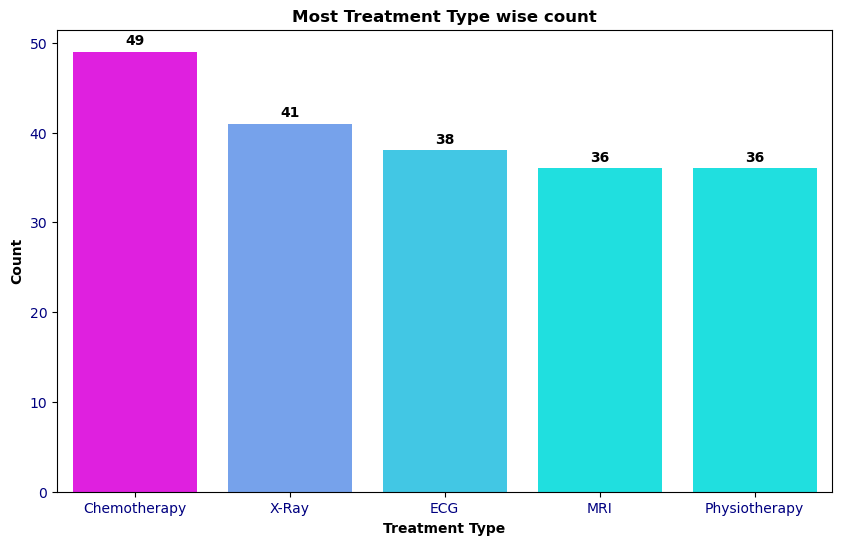

In [28]:
count_treat=treatment['treatment_type'].value_counts().reset_index()
print(count_treat)
plt.figure(figsize=(10,6))
ax=sns.barplot(data=count_treat,x='treatment_type',y='count',palette='cool',hue='count',legend=False)
plt.title('Most Treatment Type wise count',color='black',fontweight='bold')
plt.xlabel('Treatment Type',color='black',fontweight='bold')
plt.ylabel('Count',color='black',fontweight='bold')
plt.xticks(color='navy')
plt.yticks(color='navy')
for container in ax.containers:
    ax.bar_label(container,padding=3,color='black',fontweight='bold')

#  Which doctor specialization handled  patients?

  specialization  patient_id
0    Dermatology          70
1       Oncology          32
2     Pediatrics          98


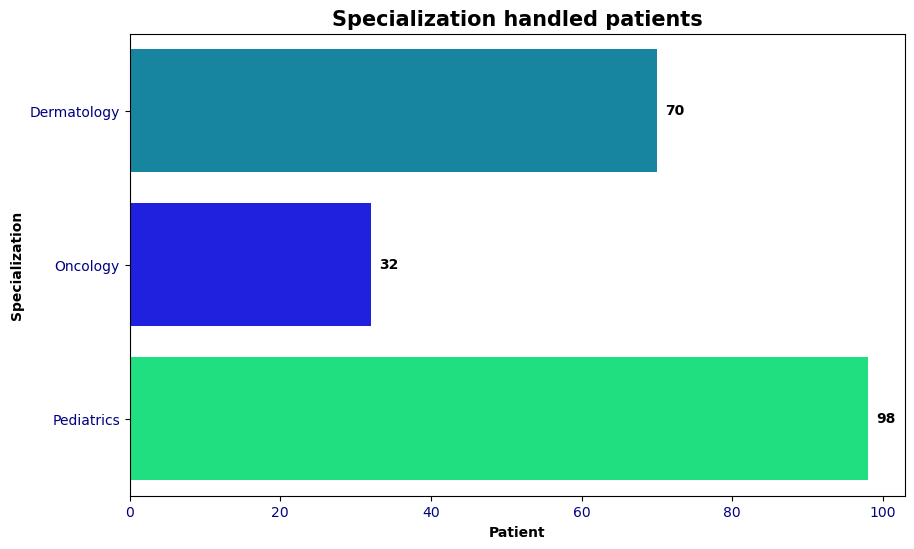

In [27]:
Specila=(doctor.merge(appointment,on='doctor_id').
    merge(patient,on='patient_id').
        groupby('specialization')['patient_id'].count().reset_index())
print(Specila)
plt.figure(figsize=(10,6))
ax=sns.barplot(data=Specila,x='patient_id',y='specialization',palette='winter',hue='patient_id',legend=False)
plt.title('Specialization handled patients',color='black',fontweight='bold',fontsize=15)
plt.xlabel('Patient',color='black',fontweight='bold')
plt.ylabel('Specialization',color='black',fontweight='bold')
plt.xticks(color='navy')
plt.yticks(color='navy')
for container in ax.containers:
    ax.bar_label(container,padding=6,color='black',fontweight='bold')

#  Find daily appointment trend.

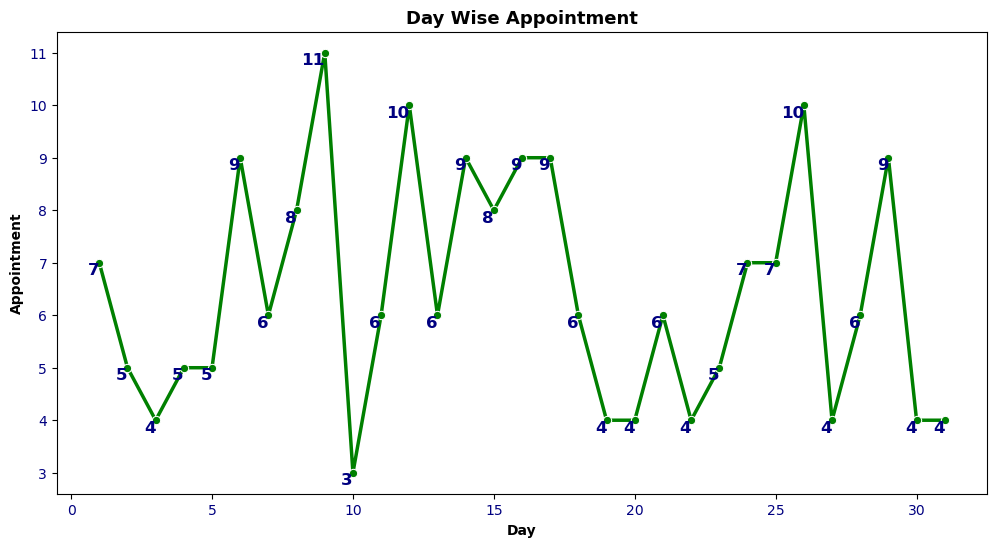

In [82]:
appointment['Day']=pd.to_datetime(appointment['appointment_date']).dt.day
day=appointment.groupby('Day')['appointment_id'].count().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=day,x='Day',y='appointment_id',marker='o',color='green',linewidth=2.5)
for i in range(len(day)):
    plt.text(
        day['Day'][i],
        day['appointment_id'][i],
        day['appointment_id'][i],ha='right',va='top',fontweight='bold',fontsize=12,color='navy')
plt.title('Day Wise Appointment',color='black',fontweight='bold',fontsize=13)
plt.xlabel('Day',color='black',fontweight='bold')
plt.ylabel('Appointment',color='black',fontweight='bold')
plt.xticks(color='navy')
plt.yticks(color='navy')
plt.show()

# Which day had the highest revenue?

In [36]:
bill['billing_day']=pd.to_datetime(bill['billing_date']).dt.day
bill.groupby('billing_day')['amount'].sum().sort_values(ascending=False).reset_index().head(1)

,billing_day,amount
0,9,14560.25


In [ ]:
# average treatment cost কত? | Find average treatment cost.

In [40]:
treatment['cost'].mean()

np.float64(2756.2492500000003)

#  Which doctor generated the highest revenue?

In [62]:
merge=appointment.merge(doctor,on='doctor_id').merge(treatment,on='appointment_id')
merge
(merge.groupby('full_name')['cost'].sum().
    sort_values(ascending=False).
        reset_index().
            rename(columns={'cost':'Revenue'}).head(1))

,full_name,Revenue
0,Sarah Taylor,82696.48


# Find gender distribution of patients.




   gender  proportion
0    Male        62.0
1  Female        38.0


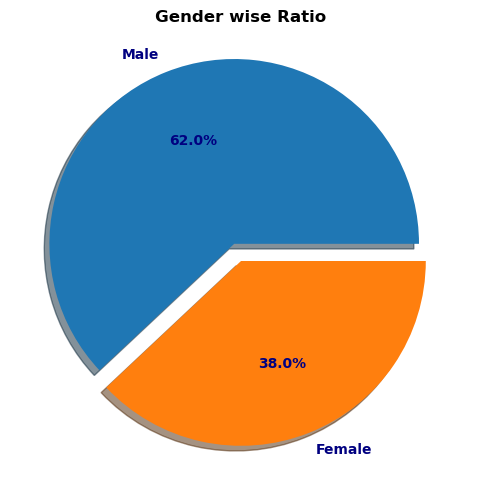

In [89]:
ratio=(patient['gender'].value_counts(normalize=True)*100).reset_index()
print(ratio)
plt.figure(figsize=(10,6))
plt.pie(ratio['proportion'],labels=ratio['gender'],autopct='%1.1f%%',
        textprops={'weight':'bold','color':'navy'},shadow=True,explode=[0.1,0])
plt.title('Gender wise Ratio',color='black',fontweight='bold')
plt.show()

# Most used insurance provider.



In [94]:
(patient.groupby('insurance_provider')['patient_id'].
    count().sort_values(ascending=False).
        reset_index().head(1).
            rename(columns={'patient_id':'most_use'}))

,insurance_provider,most_use
0,MedCare Plus,18


# Which hospital branch handled how maney patients?



In [102]:
merge=doctor.merge(appointment,on='doctor_id').merge(patient,on='patient_id')
merge.groupby('hospital_branch')['patient_id'].count().sort_values(ascending=False).reset_index()



,hospital_branch,patient_id
0,Central Hospital,84
1,Eastside Clinic,62
2,Westside Clinic,54


# Find total revenue by treatment type.




In [107]:
group.reset

treatment_type
Chemotherapy     128855.68
MRI              116098.16
X-Ray            110653.67
Physiotherapy     99418.10
ECG               96224.24
Name: cost, dtype: float64

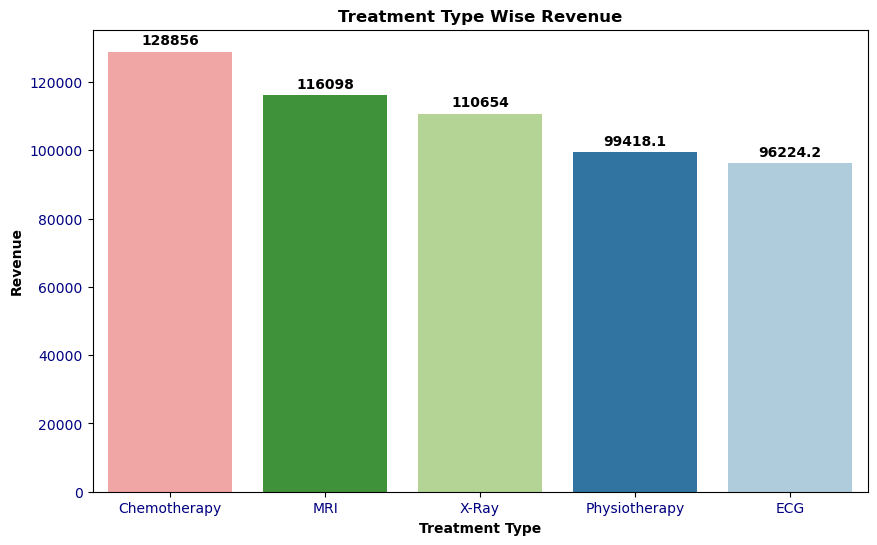

In [117]:
group=treatment.groupby('treatment_type')['cost'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
ax=sns.barplot(data=group,x='treatment_type',y='cost',palette="Paired",hue='cost',legend=False)
plt.title('Treatment Type Wise Revenue',color='black',fontweight='bold')
plt.xlabel('Treatment Type',color='black',fontweight='bold')
plt.ylabel('Revenue',color='black',fontweight='bold')
plt.xticks(color='navy')
plt.yticks(color='navy')
for container in ax.containers:
    ax.bar_label(container,padding=3,color='black',fontweight='bold')

# Which patient spent the most money?



In [136]:
(appointment.merge(treatment,on='appointment_id').
    merge(patient,on='patient_id').
        groupby('patient_name')['cost'].
    sum().sort_values(ascending=False).
    reset_index().
    rename(columns={"cost":"revenue"}).head(1))

,patient_name,revenue
0,Michael Taylor,48928.89


# Count appointments by status.



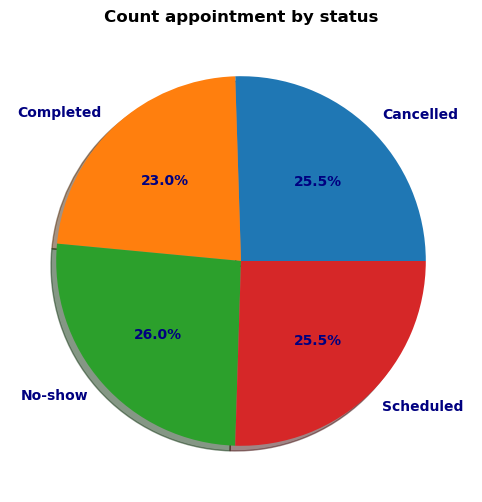

In [30]:
count=appointment.groupby('status')['appointment_id'].count().reset_index()
plt.figure(figsize=(12,6))
plt.pie(data=count,x='appointment_id',labels='status',autopct='%0.1f%%',shadow=True,textprops={'weight':'bold','color':'navy'})
plt.title('Count appointment by status',color='black',fontweight='bold')
plt.show()


# Find the most experienced doctor.



In [35]:
sort=doctor.sort_values(by='years_experience',ascending=False).head(1)
sort[['full_name','years_experience']]

,full_name,years_experience
3,David Jones,28


# Revenue in the last 30 days.



In [46]:
max_date=bill['billing_date'].max()
last_30_days=bill[bill['billing_date']>=max_date - pd.Timedelta(days=30)]

Total_Revenue=last_30_days['amount'].sum().round()
print('last_30_days_revenue:',Total_Revenue)

last_30_days_revenue: 17552.0


In [55]:
patient.head(2)

,patient_id,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email,patient_name
0,P001,Female,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com,David Williams
1,P002,Female,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com,Emily Smith


In [ ]:
20. patient age distribution বের করো | Find patient age distribution.

  age_group  count
0      0-18     21
1     31-45     12
2     19-30     10
3     46-60      6
4       60+      0


<Figure size 1200x600 with 0 Axes>

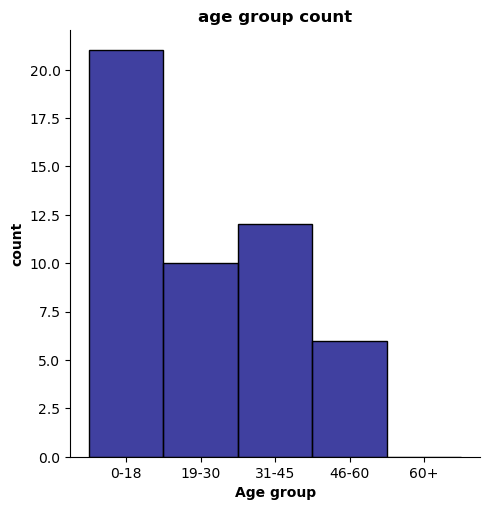

In [86]:
# dataset reference date (2020 context)
ref_date = patient['date_of_birth'].max()

# age calculate
patient['age'] = (ref_date - patient['date_of_birth']).dt.days // 365

# age group create
bins = [0, 18, 30, 45, 60, 120]
labels = ['0-18', '19-30', '31-45', '46-60', '60+']

patient['age_group'] = pd.cut(patient['age'], bins=bins, labels=labels)

# distribution
age_distribution = patient['age_group'].value_counts().reset_index()

print(age_distribution)
plt.figure(figsize=(12,6))
sns.displot(data=age_distribution,x='age_group',weights='count',kind='hist',color='navy')
plt.title('age group count',color='black',fontweight='bold')
plt.xlabel('Age group',color='black',fontweight='bold')
plt.ylabel('count',color='black',fontweight='bold')

plt.show()